In [1]:
# Import necessary libraries
import numpy as np
import os
from PIL import Image
import cv2

In [2]:
import pickle

with open("Classification_training_dataset.pkl", "rb") as f:
    data = pickle.load(f)

images_all = data["images"]
labels_all = data["labels"]

print(images_all.shape)
print(labels_all.shape)


(197, 128, 128)
(197,)


## Data Loader

In [3]:
import torch
from torchvision import transforms
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, torch.tensor(label, dtype=torch.long)


### Train-Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    images_all, labels_all, test_size=0.2, random_state=1, stratify=labels_all) #stratified to account for class imbalance

In [5]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),               
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),                     
    transforms.Normalize(mean=[0.5], std=[0.5]), 
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),               
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


In [6]:
train_ds = Dataset(X_train, y_train, transform=train_transform)
val_ds   = Dataset(X_test,  y_test,  transform=val_transform)

In [7]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

In [8]:
print("Train:", len(train_ds))
print("Val:", len(val_ds))

Train: 157
Val: 40


In [9]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)

torch.Size([32, 1, 128, 128]) torch.Size([32])


## Model Initialization

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
import torch.nn as nn
from torchvision import models

# IMAGENET WEIGHTS FOR INITIALIZATION

def make_resnet18(num_classes=2):
    model = models.resnet18(weights="IMAGENET1K_V1")
    
    weight = model.conv1.weight.clone()
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1.weight = nn.Parameter(weight.mean(dim=1, keepdim=True))

    model.fc = nn.Linear(512, num_classes)
    return model


In [12]:
model = make_resnet18(num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [13]:
import torch
import torch.nn.functional as F

class FocalLoss(torch.nn.Module): # Account for class imbalance
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, labels):
        ce = F.cross_entropy(logits, labels, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(gamma=1)

# Training

In [14]:
import time
import torch
from tqdm import tqdm

num_epochs = 50
best_val_loss = float('inf')
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [15]:
for epoch in range(1, num_epochs + 1):
    #train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    t0 = time.time()

    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += imgs.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    t_train = time.time() - t0

    # validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()

            logits = model(imgs)
            loss = criterion(logits, labels)

            val_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += imgs.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    #for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    #save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "class_model.pth")

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
        f"val_loss {val_loss:.4f} val_acc {val_acc:.4f} | "
        f"time {t_train:.1f}s"
    )


Epoch 01 | train_loss 0.6158 train_acc 0.3567 | val_loss 0.5583 val_acc 0.2250 | time 0.3s
Epoch 02 | train_loss 0.3057 train_acc 0.7070 | val_loss 0.5847 val_acc 0.2750 | time 0.1s
Epoch 03 | train_loss 0.1408 train_acc 0.8726 | val_loss 0.4282 val_acc 0.6000 | time 0.1s
Epoch 04 | train_loss 0.1139 train_acc 0.9108 | val_loss 0.2978 val_acc 0.8000 | time 0.1s
Epoch 05 | train_loss 0.0608 train_acc 0.9363 | val_loss 0.2500 val_acc 0.8250 | time 0.1s
Epoch 06 | train_loss 0.0586 train_acc 0.9427 | val_loss 0.2024 val_acc 0.8500 | time 0.1s
Epoch 07 | train_loss 0.0699 train_acc 0.9490 | val_loss 0.1697 val_acc 0.9000 | time 0.1s
Epoch 08 | train_loss 0.0298 train_acc 0.9745 | val_loss 0.1356 val_acc 0.9000 | time 0.1s
Epoch 09 | train_loss 0.0398 train_acc 0.9682 | val_loss 0.1176 val_acc 0.9500 | time 0.1s
Epoch 10 | train_loss 0.0441 train_acc 0.9745 | val_loss 0.1177 val_acc 0.9250 | time 0.1s
Epoch 11 | train_loss 0.0416 train_acc 0.9618 | val_loss 0.1182 val_acc 0.9000 | time 0.1s

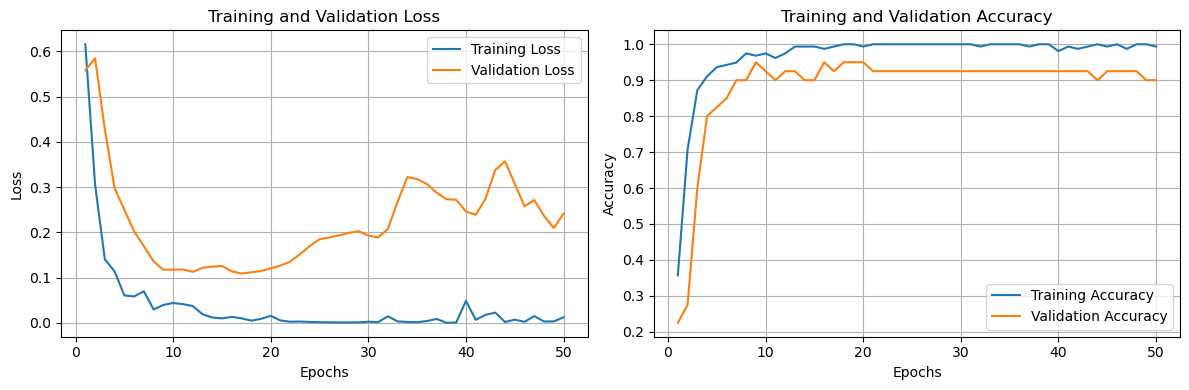

In [16]:
#Plot after training
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

#Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

#Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
from collections import Counter
train_labels = []
val_labels = []
for _, y in train_loader:
    train_labels += y.tolist()
for _, y in val_loader:
    val_labels += y.tolist()
print("train dist:", Counter(train_labels))
print("val   dist:", Counter(val_labels))


train dist: Counter({0: 121, 1: 36})
val   dist: Counter({0: 31, 1: 9})


# Test Loader

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = make_resnet18(num_classes=2)
model1.load_state_dict(torch.load("class_model.pth", map_location=device))
model1.to(device)

print("Model loaded!")

Model loaded!


/tmp/ipykernel_4139428/3622909453.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load("class_model.pth", map_location=device))


In [21]:
with open("classification_test_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(data["images"].shape)
print(data["labels"].shape)

(23, 128, 128)
(23,)


In [22]:
images_all_test = data["images"]
labels_all_test = data["labels"]

In [23]:
test_ds   = Dataset(images_all_test,  labels_all_test,  transform=val_transform)

In [24]:
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False)

## Model Evaluation

In [25]:
import numpy as np
model1.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model1(imgs)

        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

## Model Performance

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))


Confusion Matrix:
 [[15  1]
 [ 2  5]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8824    0.9375    0.9091        16
           1     0.8333    0.7143    0.7692         7

    accuracy                         0.8696        23
   macro avg     0.8578    0.8259    0.8392        23
weighted avg     0.8674    0.8696    0.8665        23



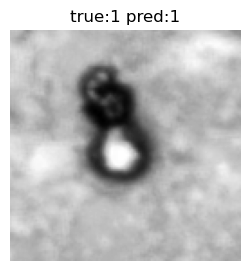

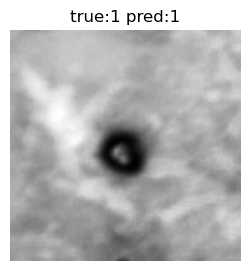

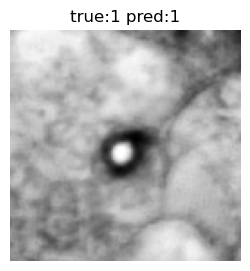

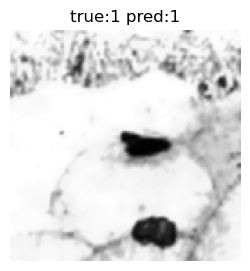

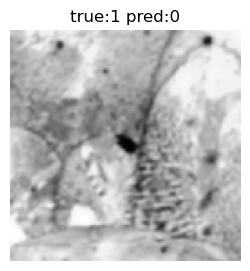

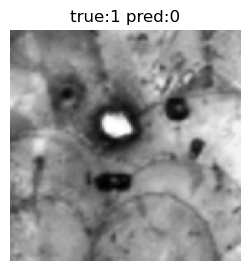

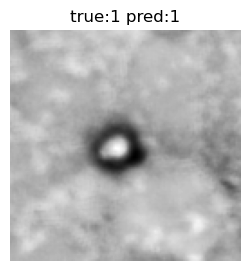

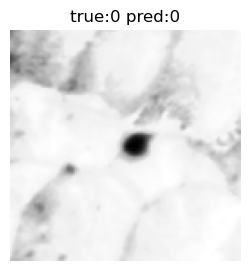

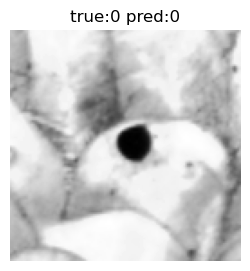

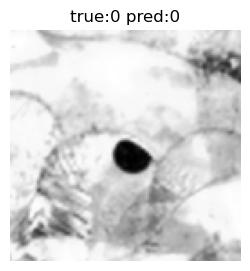

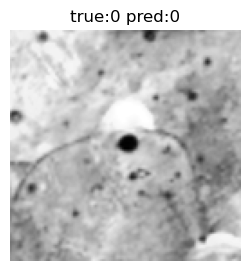

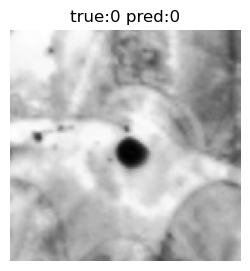

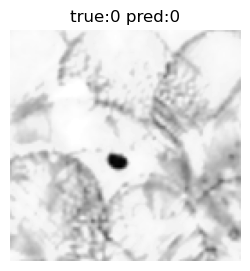

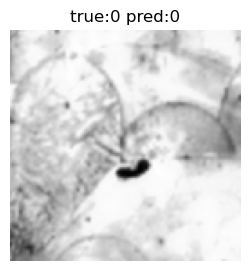

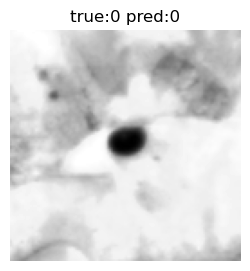

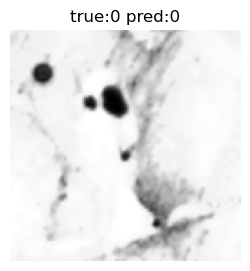

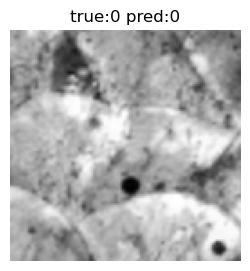

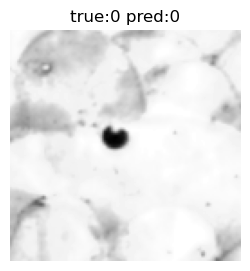

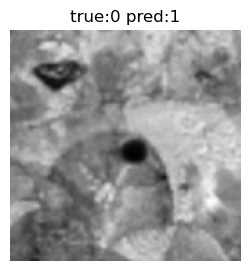

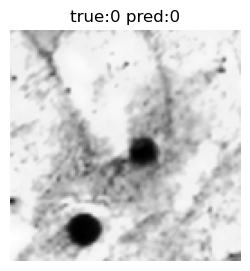

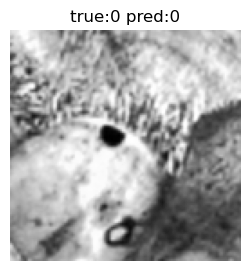

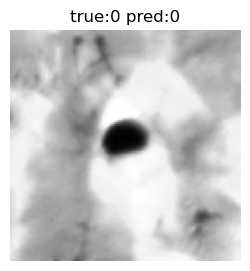

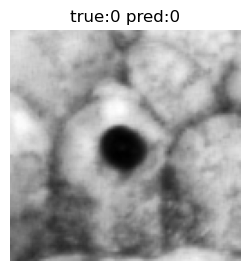

In [27]:
import matplotlib.pyplot as plt
model1.eval()
imgs, labels = next(iter(test_loader))
logits = model1(imgs.to(device))
preds = logits.argmax(dim=1).cpu()
for i in range(min(26, len(imgs))):
    plt.figure(figsize=(3,3))
    im = imgs[i].squeeze().cpu().numpy()
    plt.imshow(im, cmap='gray'); plt.title(f"true:{labels[i].item()} pred:{preds[i].item()}"); plt.axis('off')
    plt.show()
